<a href="https://colab.research.google.com/github/SANGDEENA/Campus-navigation-Mobile-App/blob/main/Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score,confusion_matrix,
                             classification_report,precision_score,
                             recall_score,f1_score, roc_curve,
                             roc_auc_score)

In [ ]:
from google.colab import files

In [ ]:
from google.colab import files
print("UPLOAD CUSTOMER CHURN DATASET")
uploaded = files.upload()
data = pd.read_csv("customer_churn_dataset.csv")
print("\nDATASET LOADED SUCCESSFULLY\n")

UPLOAD CUSTOMER CHURN DATASET


Saving customer_churn_dataset.csv to customer_churn_dataset.csv

DATASET LOADED SUCCESSFULLY



In [ ]:
print(data.head())

  customer_id  age  tenure service_type  monthly_fee  churn
0       C1000   56      14       bundle        47.54      0
1       C1001   69      63           tv        31.89      0
2       C1002   46      27           tv       129.43      0
3       C1003   32      38       bundle        16.51      0
4       C1004   60      56           tv        96.76      0


In [ ]:

print(data.tail())

    customer_id  age  tenure service_type  monthly_fee  churn
995       C1995   60      11       mobile        53.80      1
996       C1996   64       4           tv       140.94      1
997       C1997   62      47       mobile       129.10      1
998       C1998   35      36     internet       147.47      0
999       C1999   55      43     internet        97.92      0


In [ ]:
print("\nDataset Shape")
print(data.shape)


Dataset Shape
(1000, 6)


In [ ]:
print("\nDataset Information")
data.info()


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   customer_id   1000 non-null   object 
 1   age           1000 non-null   int64  
 2   tenure        1000 non-null   int64  
 3   service_type  1000 non-null   object 
 4   monthly_fee   1000 non-null   float64
 5   churn         1000 non-null   int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 47.0+ KB


In [ ]:

print(data.isnull().sum())


customer_id     0
age             0
tenure          0
service_type    0
monthly_fee     0
churn           0
dtype: int64


In [ ]:

print(data.duplicated().sum())

0


In [ ]:
print("\nStatistical Summary")
print(data.describe())


Statistical Summary
              age       tenure  monthly_fee        churn
count  1000.00000  1000.000000  1000.000000  1000.000000
mean     43.81900    35.083000    80.999070     0.257000
std      14.99103    20.778302    40.736483     0.437198
min      18.00000     0.000000    10.030000     0.000000
25%      31.00000    17.000000    45.582500     0.000000
50%      44.00000    35.000000    83.345000     0.000000
75%      56.00000    53.000000   116.527500     1.000000
max      69.00000    71.000000   149.960000     1.000000


In [ ]:
print("\nChurn Distribution")
print(data["churn"].value_counts())


Churn Distribution
churn
0    743
1    257
Name: count, dtype: int64


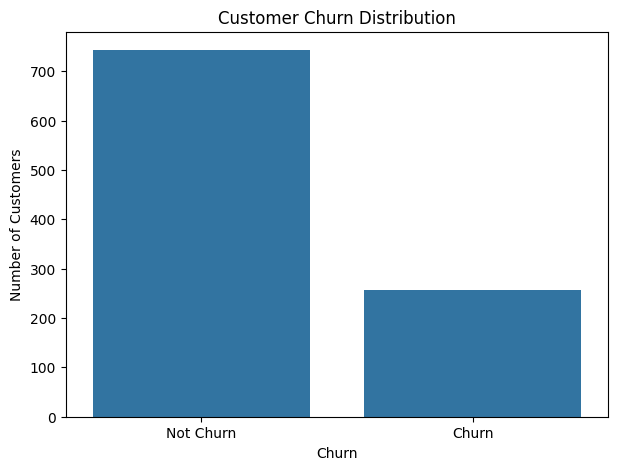

In [ ]:
plt.figure(figsize=(7, 5))
sns.countplot(x="churn",data=data)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks([0, 1],["Not Churn", "Churn"])
plt.show()

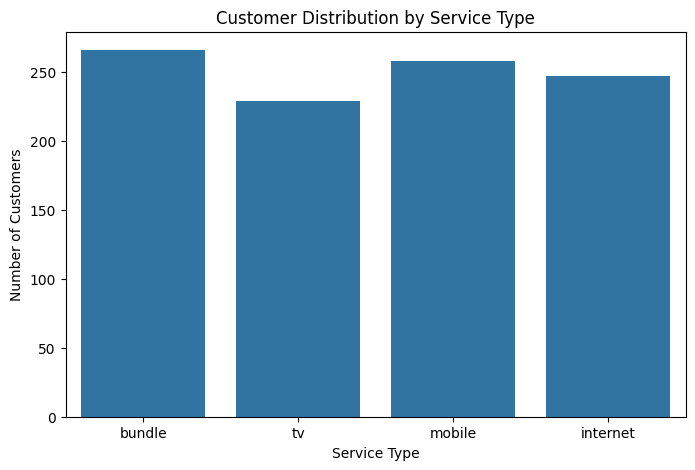

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x="service_type",data=data)
plt.title("Customer Distribution by Service Type")
plt.xlabel("Service Type")
plt.ylabel("Number of Customers")
plt.show()

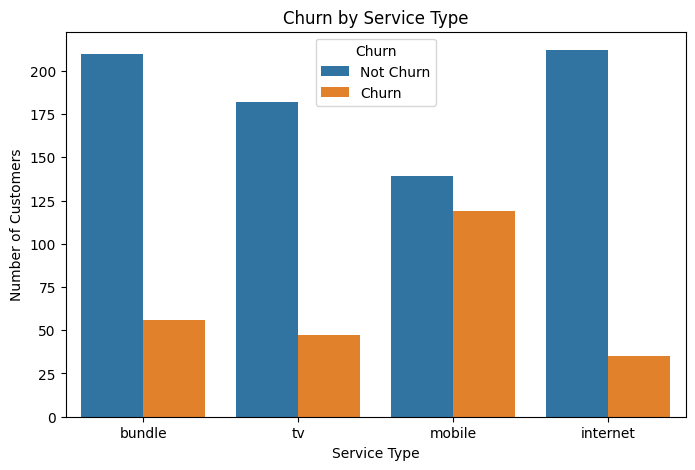

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x="service_type",hue="churn",data=data)
plt.title("Churn by Service Type")
plt.xlabel("Service Type")
plt.ylabel("Number of Customers")
plt.legend(title="Churn",labels=["Not Churn","Churn"])
plt.show()



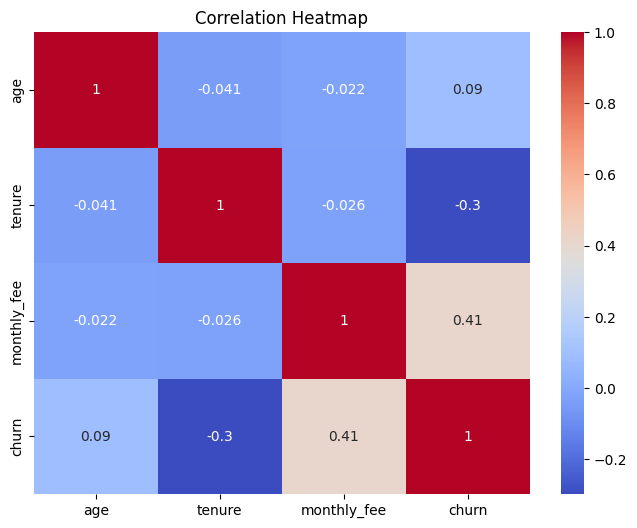

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(data.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
data_model = data.drop("customer_id",axis=1)

In [ ]:
data_model = pd.get_dummies(data_model,columns=["service_type"],dtype=int)
print("\nProcessed Dataset")
print(data_model.head())


Processed Dataset
   age  tenure  monthly_fee  churn  service_type_bundle  \
0   56      14        47.54      0                    1   
1   69      63        31.89      0                    0   
2   46      27       129.43      0                    0   
3   32      38        16.51      0                    1   
4   60      56        96.76      0                    0   

   service_type_internet  service_type_mobile  service_type_tv  
0                      0                    0                0  
1                      0                    0                1  
2                      0                    0                1  
3                      0                    0                0  
4                      0                    0                1  


In [ ]:
X = data_model.drop("churn",axis=1)
y = data_model["churn"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,
    stratify=y)
print("\nTraining Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)


Training Shape : (800, 7)
Testing Shape  : (200, 7)


In [ ]:
model = RandomForestClassifier(n_estimators=100,random_state=42,
                               class_weight="balanced")


In [ ]:
model.fit(X_train,y_train)
print("\nMODEL TRAINED SUCCESSFULLY")



MODEL TRAINED SUCCESSFULLY


In [ ]:
prediction = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test,prediction)
precision = precision_score(y_test,prediction,zero_division=0)
recall = recall_score(y_test,prediction,zero_division=0)
f1 = f1_score(y_test,prediction,zero_division=0)
print("\n")
print("MODEL EVALUATION")
print()
print("Accuracy :",round(accuracy * 100, 2),"%")
print("Precision :",round(precision * 100, 2),"%")
print("Recall :",round(recall * 100, 2),"%")
print("F1 Score :",round(f1 * 100, 2),"%")




MODEL EVALUATION

Accuracy : 100.0 %
Precision : 100.0 %
Recall : 100.0 %
F1 Score : 100.0 %


In [ ]:
cm = confusion_matrix(y_test,prediction)
print("\nConfusion Matrix")
print(cm)



Confusion Matrix
[[149   0]
 [  0  51]]


In [ ]:
print("\nClassification Report")
print(
    classification_report(y_test,prediction,
        target_names=["Not Churn","Churn"],zero_division=0))



Classification Report
              precision    recall  f1-score   support

   Not Churn       1.00      1.00      1.00       149
       Churn       1.00      1.00      1.00        51

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



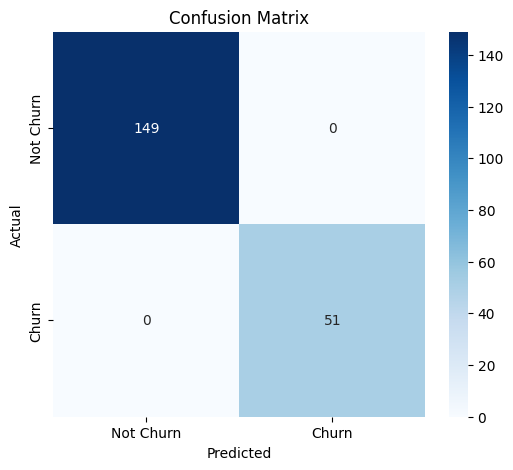

In [ ]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm,annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Churn","Churn"],yticklabels=["Not Churn","Churn"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


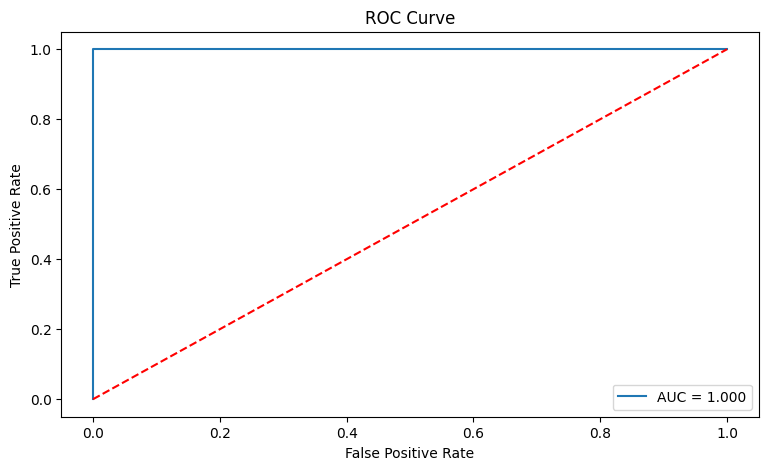


ROC-AUC Score :
1.0


In [ ]:
probability = model.predict_proba(X_test)
fpr, tpr, threshold = roc_curve(y_test,probability[:, 1])
auc = roc_auc_score(y_test,probability[:, 1])
plt.figure(figsize=(9, 5))
plt.plot(fpr,tpr,label="AUC = %.3f" % auc)
plt.plot([0, 1],[0, 1],"r--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
print("\nROC-AUC Score :")
print(round(auc, 3))

In [ ]:
importance = model.feature_importances_
feature = X.columns
feature_importance = pd.DataFrame({
        "Feature": feature,
        "Importance": importance
        })
feature_importance = feature_importance.sort_values(by="Importance",ascending=False)
print("\nFeature Importance")
print(feature_importance)




Feature Importance
                 Feature  Importance
2            monthly_fee    0.393561
1                 tenure    0.254623
0                    age    0.235116
5    service_type_mobile    0.072708
4  service_type_internet    0.018236
3    service_type_bundle    0.014365
6        service_type_tv    0.011391


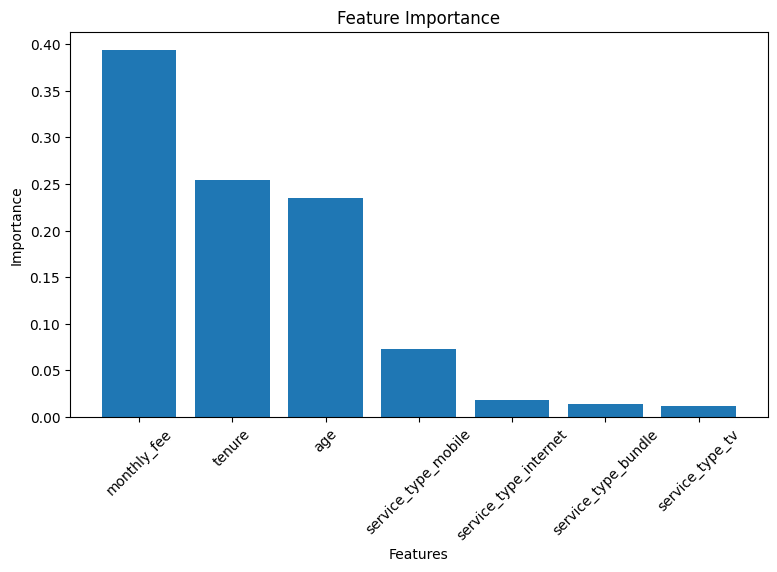

In [ ]:
plt.figure(figsize=(9, 5))
plt.bar(feature_importance["Feature"],feature_importance["Importance"])
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

In [ ]:
sample = pd.DataFrame({
        "age": [35],
        "tenure": [5],
        "monthly_fee": [120.00],
        "service_type_bundle": [0],
        "service_type_internet": [0],
        "service_type_mobile": [0],
        "service_type_tv": [1]
    }
)

In [ ]:
sample = sample[X.columns]


In [ ]:
result = model.predict(sample)
prob = model.predict_proba(sample)
print("\n")
print("NEW CUSTOMER PREDICTION")
if result[0] == 1:
    print("Prediction : Customer Will Churn")
    print("Risk Level : HIGH")
else:
    print("Prediction : Customer Will Not Churn")
    print("Risk Level : LOW")
print("\nProbability")
print("Not Churn :", round(prob[0][0] * 100, 2), "%")
print("Churn     :", round(prob[0][1] * 100, 2), "%")




NEW CUSTOMER PREDICTION
Prediction : Customer Will Churn
Risk Level : HIGH

Probability
Not Churn : 15.0 %
Churn     : 85.0 %
